# Does Higher Usage Rate Trade Off Against Shooting Efficiency in the NBA?

A common narrative in basketball analytics is that players who take on a bigger offensive role, measured by usage rate, sacrifice shooting efficiency to do it. This analysis tests that claim using real 2024-25 NBA season data.

**Data source:** [NBA GameLogs 2024-25](https://www.kaggle.com/datasets/joopaivaaaaaaa/nba-gamelogs-2024-25), Kaggle. Note: despite the dataset's name, it contains season-level aggregate statistics per player, not individual game logs, a mismatch discovered during initial data exploration and accounted for below.

**Method:** Pearson correlation between usage rate and true shooting percentage, followed by a two-sample t-test comparing shooting efficiency between high-usage and low-usage players.

**Finding:** No statistically significant relationship found, players with higher usage rates are not meaningfully less (or more) efficient shooters than players with lower usage rates in this dataset.

## Loading and Inspecting the Data

Before analyzing anything, the dataset's actual structure needs to be confirmed rather than assumed.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("nba_gamelogs.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)

(522, 123)
['Unnamed: 0', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'E_OFF_RATING', 'OFF_RATING', 'sp_work_OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'sp_work_DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'sp_work_NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 

Initial inspection revealed 522 rows and 123 columns, one row per player, with columns like `GP` (games played) and season-long aggregate stats. This confirmed the dataset contains **season-level averages, not individual game logs** despite its filename. A game-by-game hot streak analysis, the original plan, isn't possible with this data. The question was pivoted to a season-level comparison instead: does usage rate correlate with shooting efficiency across players?

Players with unreliably small minutes are filtered out before any analysis, using a threshold of 15+ minutes per game.

In [2]:
#checking for missing values in relevant columns
print(df[["MIN", "GP", "USG_PCT", "TS_PCT"]].isna().sum())
print(df["MIN"].describe())

#Filtering out low-minute players since their stats are unreliable in small samples
filtered = df[df["MIN"] >= 15].copy()
print(filtered.shape)

MIN        0
GP         0
USG_PCT    0
TS_PCT     0
dtype: int64
count    522.000000
mean      18.945019
std       10.262077
min        1.500000
25%        9.900000
50%       19.050000
75%       27.775000
max       38.600000
Name: MIN, dtype: float64
(326, 123)


## Visualizing and Testing the Relationship

A scatter plot of usage rate against true shooting percentage, filtered to players with a meaningful role, shows no obvious linear pattern. This is confirmed numerically with a Pearson correlation coefficient.

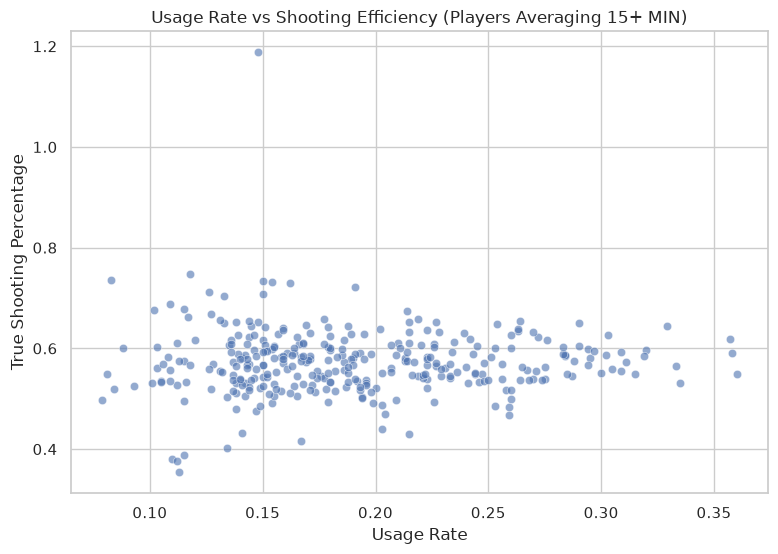

Correlation: 0.01205923418350283


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=filtered, x="USG_PCT", y="TS_PCT", alpha=0.6)
plt.xlabel("Usage Rate")
plt.ylabel("True Shooting Percentage")
plt.title("Usage Rate vs Shooting Efficiency (Players Averaging 15+ MIN)")
plt.show()

correlation = filtered["USG_PCT"].corr(filtered["TS_PCT"])
print(f"Correlation: {correlation}")

In [4]:
#checking for the observation over 100 shooting %
print(filtered[filtered["TS_PCT"] > 1.0])

     Unnamed: 0  PLAYER_ID      PLAYER_NAME NICKNAME     TEAM_ID  \
103         103    1631342  Daeqwon Plowden  Daeqwon  1610612737   

    TEAM_ABBREVIATION   AGE  GP  W  L  ...  EFG_PCT_RANK  TS_PCT_RANK  \
103               ATL  26.0   1  1  0  ...             2            2   

     USG_PCT_RANK  E_USG_PCT_RANK  E_PACE_RANK  PACE_RANK  sp_work_PACE_RANK  \
103           352             363          265        167                167   

     PIE_RANK  FGM_PG_RANK  FGA_PG_RANK  
103        12           52          170  

[1 rows x 123 columns]


The initial scatter plot revealed an impossible outlier, a true shooting percentage above 1.0. Investigating it showed the player had only 1 game played, meaning the 15+ minutes filter alone wasn't sufficient to guarantee a meaningful sample. The filter was corrected to require both 15+ minutes per game and 10+ games played, a more defensible standard for "meaningful role" than minutes alone, and the correlation recomputed on the corrected data.

In [5]:
#correct filtered data to include a games played minimum
filtered = df[(df["MIN"] >= 15) & (df["GP"] >= 10)].copy()
print(filtered.shape)

correlation = filtered["USG_PCT"].corr(filtered["TS_PCT"])
print(f"Correlation: {correlation}")

(313, 123)
Correlation: 0.03481050159727853


A correlation coefficient only captures linear relationships. To test more directly whether high-usage and low-usage players differ in efficiency, players were split into two groups by median usage rate, and their true shooting percentages compared with an independent two-sample t-test.

In [6]:
median_usage = filtered["USG_PCT"].median()
high_usage = filtered[filtered["USG_PCT"] > median_usage]["TS_PCT"]
low_usage = filtered[filtered["USG_PCT"] <= median_usage]["TS_PCT"]

print(f"High usage group mean TS_PCT: {high_usage.mean()}")
print(f"Low usage group mean TS_PCT: {low_usage.mean()}")

t_stat, p_value = stats.ttest_ind(high_usage, low_usage)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

High usage group mean TS_PCT: 0.5722105263157895
Low usage group mean TS_PCT: 0.5722484472049689
T-statistic: -0.006289269661049692
P-value: 0.9949859542236353


## Conclusion

Two independent methods, a Pearson correlation and a two-sample t-test, both point to the same result: there is no statistically significant relationship between usage rate and shooting efficiency among NBA players with a meaningful role (15+ minutes per game, 10+ games played) in the 2024-25 season.

- Correlation between usage rate and true shooting percentage: 0.035, effectively zero
- Two-sample t-test comparing high-usage versus low-usage players: p = 0.995, no significant difference

This contradicts a common basketball analytics narrative that taking on a larger offensive role forces a tradeoff in efficiency. At least in this season's data, high-usage players are not meaningfully less efficient shooters than their lower-usage counterparts.

**Limitations:** This is a single-season, correlational analysis. It does not account for player position, team system, or role changes within a season, and it cannot establish causation in either direction. A logical next step would be a multi-season analysis or a regression controlling for additional variables like position and shot type.

## Extension: Controlling for Minutes Played

The limitations above noted that this analysis doesn't control for confounding variables. Position data wasn't available in this dataset, but minutes played is a reasonable alternative confound to test, players who log more minutes tend to be more established and trusted with the ball, which could independently affect efficiency regardless of usage rate.

In [7]:
import statsmodels.api as sm

x = filtered[["USG_PCT", "MIN"]]
x = sm.add_constant(x)
y= filtered["TS_PCT"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 TS_PCT   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     3.688
Date:                Fri, 11 Sep 2026   Prob (F-statistic):             0.0261
Time:                        18:26:19   Log-Likelihood:                 478.13
No. Observations:                 313   AIC:                            -950.3
Df Residuals:                     310   BIC:                            -939.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5448      0.013     41.732      0.0

### Interpreting the Regression

Even after controlling for minutes played, usage rate still shows no statistically significant relationship with shooting efficiency (coefficient = -0.0598, p = 0.335). This confirms the original finding: the apparent tradeoff between usage rate and efficiency is not supported by this season's data, even under a more rigorous test.

Minutes played, on the other hand, does show a small but statistically significant positive relationship with efficiency (coefficient = 0.0015, p = 0.009), players with more playing time tend to be slightly more efficient shooters, independent of their usage rate. This was worth controlling for, and it turned out to be a real factor, it just doesn't change the conclusion about usage rate itself.

The model's R-squared is low (0.023), meaning usage rate and minutes together explain very little of the overall variation in shooting efficiency. Whatever actually drives shooting efficiency, likely shot selection, position, or individual skill, isn't well captured by these two variables. This reinforces rather than undermines the core finding: usage rate specifically is not a meaningful predictor of efficiency, even though other factors clearly matter more.

**Updated conclusion:** The original finding holds under a more rigorous test. Controlling for playing time, higher usage rate is not associated with lower shooting efficiency in this dataset.